# 02 - Atmospheric Surface Air Temperature

Create a CMIP7 monthly near-surface air temperature file (`tas_tavg-h2m-hxy-u`). This adds the CMIP7 fixed-height coordinate used for 2 m variables.

In [1]:
from pathlib import Path
import json
import shutil

import cmor
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import numpy as np
import xarray as xr

start = Path.cwd().resolve()
for candidate in (start, *start.parents):
    if (candidate / "notebooks" / "NOTEBOOKS.md").exists() or (candidate / ".git").exists():
        REPO_ROOT = candidate
        break
else:
    REPO_ROOT = start

TABLES_REPO = REPO_ROOT / "cmip7-cmor-tables"
TABLES_DIR = TABLES_REPO / "tables"
if not TABLES_DIR.exists():
    raise FileNotFoundError(f"CMIP7 tables directory not found: {TABLES_DIR}")

CV_FILE_FROM_TABLES_DIR = "../tables-cvs/cmor-cvs.json"

print(f"Using CMIP7 tables from {TABLES_REPO}")


Using CMIP7 tables from /Users/mauzey1/Desktop/github/cmor/cmip7-cmor-tables


In [2]:
run_dir = REPO_ROOT / "notebooks" / "output" / "02_atmos_surface_air_temperature"
if run_dir.exists():
    shutil.rmtree(run_dir)
output_dir = run_dir / "cmor_output"
output_dir.mkdir(parents=True)

DATASET_INFO = {
    "_AXIS_ENTRY_FILE": "CMIP7_coordinate.json",
    "_FORMULA_VAR_FILE": "CMIP7_formula_terms.json",
    "_cmip7_option": 1,
    "_controlled_vocabulary_file": CV_FILE_FROM_TABLES_DIR,
    "activity_id": "CMIP",
    "calendar": "360_day",
    "drs_specs": "MIP-DRS7",
    "experiment_id": "amip",
    "forcing_index": "f3",
    "frequency": "mon",
    "grid_label": "g999",
    "host_collection": "CMIP7",
    "initialization_index": "i1",
    "institution_id": "CCCma",
    "license_id": "CC-BY-4.0",
    "mip_era": "CMIP7",
    "nominal_resolution": "100 km",
    "outpath": str(output_dir),
    "physics_index": "p1",
    "realization_index": "r9",
    "region": "glb",
    "source_id": "DUMMY-MODEL",
    "tracking_prefix": "hdl:21.14107",
}
input_json = run_dir / "input.json"
input_json.write_text(json.dumps(DATASET_INFO, indent=2, sort_keys=True))

lat = np.arange(-85.0, 90.0, 10.0)
lat_bnds = np.arange(-90.0, 91.0, 10.0)
lon = np.arange(5.0, 360.0, 10.0)
lon_bnds = np.arange(0.0, 361.0, 10.0)
time = 15.0 + 30.0 * np.arange(3, dtype="f8")
time_bnds = 30.0 * np.arange(4, dtype="f8")
time_units = "days since 2018-01-01"

seasonal_cycle = np.array([-5.0, -1.0, 3.0], dtype="f4")[:, None, None, None]
lat_term = np.sin(np.deg2rad(lat))[None, None, :, None] ** 2
lon_term = np.cos(np.deg2rad(lon))[None, None, None, :]
tas = (288.0 - 45.0 * lat_term + 2.0 * lon_term + seasonal_cycle).astype("f4")

tas.shape


(3, 1, 18, 36)

In [3]:
cmor.setup(
    inpath=str(TABLES_DIR),
    netcdf_file_action=cmor.CMOR_REPLACE,
    logfile=str(run_dir / "cmor.log"),
)
cmor.dataset_json(str(input_json))
cmor.load_table("CMIP7_atmos.json")

time_id = cmor.axis("time", coord_vals=time, cell_bounds=time_bnds, units=time_units)
height_id = cmor.axis("height2m", coord_vals=np.array([2.0]), units="m")
lat_id = cmor.axis("latitude", coord_vals=lat, cell_bounds=lat_bnds, units="degrees_north")
lon_id = cmor.axis("longitude", coord_vals=lon, cell_bounds=lon_bnds, units="degrees_east")

variable_name = "tas_tavg-h2m-hxy-u"
tas_id = cmor.variable(variable_name, "K", [time_id, height_id, lat_id, lon_id])
compound_name = ".".join(["atmos"] + variable_name.split("_") + ["mon", "glb"])

with open(TABLES_DIR / "CMIP7_cell_measures.json") as handle:
    cell_measure = json.load(handle)["cell_measures"].get(compound_name)
if cell_measure:
    cmor.set_variable_attribute(tas_id, "cell_measures", "c", cell_measure)

with open(TABLES_DIR / "CMIP7_long_name_overrides.json") as handle:
    long_name = json.load(handle)["long_name_overrides"].get(compound_name)
if long_name:
    cmor.set_variable_attribute(tas_id, "long_name", "c", long_name)

cmor.write(tas_id, tas)
netcdf_path = Path(cmor.close(tas_id, file_name=True))
cmor.close()

netcdf_path


PosixPath('/Users/mauzey1/Desktop/github/cmor/notebooks/output/02_atmos_surface_air_temperature/cmor_output/MIP-DRS7/CMIP7/CMIP/CCCma/DUMMY-MODEL/amip/r9i1p1f3/glb/mon/tas/tavg-h2m-hxy-u/g999/v20260529/tas_tavg-h2m-hxy-u_mon_glb_g999_DUMMY-MODEL_amip_r9i1p1f3_201801-201803.nc')

In [4]:
with xr.open_dataset(netcdf_path, decode_times=False) as opened:
    ds = opened.load()
ds


<xarray.Dataset> Size: 9kB
Dimensions:    (time: 3, bnds: 2, lat: 18, lon: 36)
Coordinates:
  * time       (time) float64 24B 15.0 45.0 75.0
  * lat        (lat) float64 144B -85.0 -75.0 -65.0 -55.0 ... 65.0 75.0 85.0
  * lon        (lon) float64 288B 5.0 15.0 25.0 35.0 ... 325.0 335.0 345.0 355.0
    height     float64 8B 2.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) float64 48B 0.0 30.0 30.0 60.0 60.0 90.0
    lat_bnds   (lat, bnds) float64 288B -90.0 -80.0 -80.0 ... 80.0 80.0 90.0
    lon_bnds   (lon, bnds) float64 576B 0.0 10.0 10.0 20.0 ... 350.0 350.0 360.0
    tas        (time, lat, lon) float32 8kB 240.3 240.3 240.2 ... 248.3 248.3
Attributes: (12/40)
    Conventions:           CF-1.12
    activity_id:           CMIP
    area_label:            u
    branded_variable:      tas_tavg-h2m-hxy-u
    branding_suffix:       tavg-h2m-hxy-u
    creation_date:         2026-05-29T21:02:59Z
    ...                    ...
    tracking_id:           hdl:21.14107/981933d1-7b64-4ace-a7dd-77c58ff78c0a
    variable_id:           tas
    variant_label:         r9i1p1f3
    vertical_label:        h2m
    license:               CC-BY-4.0; CMIP7 data produced by CCCma is license...
    cmor_version:          3.15.1

In [5]:
for name in ["branded_variable", "vertical_label", "horizontal_label", "area_label", "frequency", "region"]:
    print(f"{name}: {ds.attrs.get(name)}")
print(f"\nheight coordinate: {float(ds['height'].values)} {ds['height'].attrs.get('units')}")
print(f"Variable attributes: {dict(ds['tas'].attrs)}")


branded_variable: tas_tavg-h2m-hxy-u
vertical_label: h2m
horizontal_label: hxy
area_label: u
frequency: mon
region: glb

height coordinate: 2.0 m
Variable attributes: {'standard_name': 'air_temperature', 'long_name': 'Near-Surface Air Temperature', 'units': 'K', 'cell_methods': 'area: time: mean', 'history': "2026-05-29T21:02:59Z altered by CMOR: Treated scalar dimension: 'height'.", 'cell_measures': 'area: areacella'}


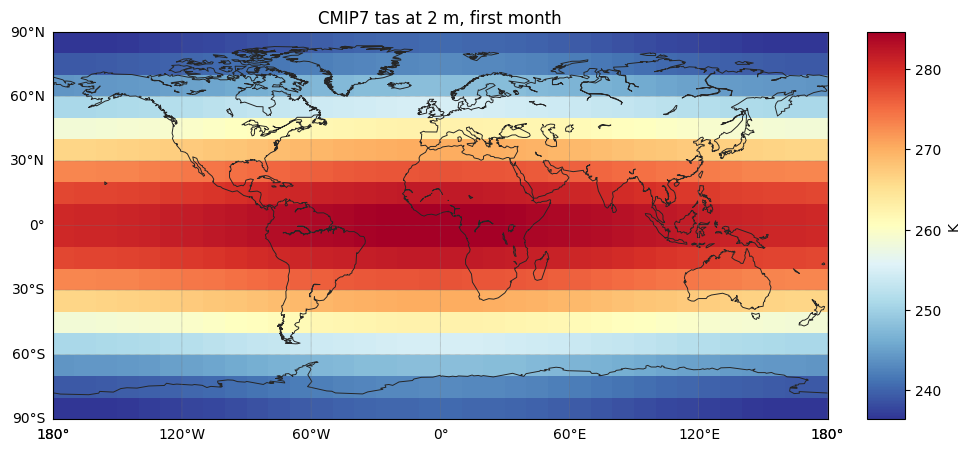

In [6]:
fig, ax = plt.subplots(figsize=(11, 5.4))
map_plot = Basemap(
    projection="cyl",
    llcrnrlon=-180,
    urcrnrlon=180,
    llcrnrlat=-90,
    urcrnrlat=90,
    resolution="c",
    ax=ax,
)
map_plot.drawmapboundary(fill_color="#f7fbff", linewidth=0.8)
lon_wrapped = ((ds["lon"].values + 180.0) % 360.0) - 180.0
lon_order = np.argsort(lon_wrapped)
lon_grid, lat_grid = np.meshgrid(lon_wrapped[lon_order], ds["lat"].values)
x, y = map_plot(lon_grid, lat_grid)
field = ds["tas"].isel(time=0).values[:, lon_order]
mesh = map_plot.pcolormesh(x, y, field, shading="auto", cmap="RdYlBu_r")
map_plot.drawcoastlines(linewidth=0.7, color="0.15")
map_plot.drawparallels(np.arange(-90, 91, 30), labels=[1, 0, 0, 0], linewidth=0.4, color="0.45", dashes=[1, 1])
map_plot.drawmeridians(np.arange(-180, 181, 60), labels=[0, 0, 0, 1], linewidth=0.4, color="0.45", dashes=[1, 1])
colorbar = map_plot.colorbar(mesh, location="right", pad="5%")
colorbar.set_label("K")
ax.set_title("CMIP7 tas at 2 m, first month")
plt.show()
